# 1. Imports Libraries
This section imports the necessary libraries for data manipulation, building the Naïve Bayes classifier, and visualizing the Correct Classification Rate (CCR) progress.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

# 2. Data Loading and Preprocessing
We load the `TinyMNIST` dataset containing training and test subsets, and convert them to one-dimensional arrays for labels and matrices for features. This ensures fast indexing during the iterative feature selection process.

In [2]:
X_train = pd.read_csv('TinyMNIST/trainData.csv', header=None).to_numpy()
X_test = pd.read_csv('TinyMNIST/testData.csv', header=None).to_numpy()
y_train = pd.read_csv('TinyMNIST/trainLabels.csv', header=None).to_numpy().ravel()
y_test = pd.read_csv('TinyMNIST/testLabels.csv', header=None).to_numpy().ravel()

if X_train.shape[0] != y_train.shape[0]:
    y_train = y_train[:X_train.shape[0]]

print(f'Training data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')

Training data shape: (5000, 196)
Test data shape: (2500, 196)


# 3. Forward Feature Selection Implementation
The Forward Selection algorithm begins with an empty set of features. At each step, it evaluates all remaining available features, adds the one that maximizes the classification accuracy (CCR) of the Naïve Bayes optimal classifier, and permanently includes it in our selected feature set.

In [3]:
clf = GaussianNB()
n_features = X_train.shape[1]

selected_features_fw = []
best_scores_fw = []
available_features = list(range(n_features))

for step in range(n_features):
    best_score = -1
    best_feature = -1

    for feature in available_features:
        current_features = selected_features_fw + [feature]
        clf.fit(X_train[:, current_features], y_train)
        y_pred = clf.predict(X_test[:, current_features])
        score = accuracy_score(y_test, y_pred)

        if score > best_score:
            best_score = score
            best_feature = feature

    selected_features_fw.append(best_feature)
    available_features.remove(best_feature)
    best_scores_fw.append(best_score)

    if (step + 1) % 20 == 0 or step == 0:
        print(f'Step {step+1}: Max CCR = {best_score:.4f} with {len(selected_features_fw)} features')

Step 1: Max CCR = 0.2212 with 1 features
Step 20: Max CCR = 0.7596 with 20 features
Step 40: Max CCR = 0.7888 with 40 features
Step 60: Max CCR = 0.7992 with 60 features
Step 80: Max CCR = 0.7976 with 80 features
Step 100: Max CCR = 0.7952 with 100 features
Step 120: Max CCR = 0.7740 with 120 features
Step 140: Max CCR = 0.7432 with 140 features
Step 160: Max CCR = 0.6852 with 160 features
Step 180: Max CCR = 0.6392 with 180 features


# 4. Backward Feature Elimination Implementation
The Backward Elimination algorithm starts with the complete set of features. At each iterative step, it tests removing each currently selected feature one by one. The feature whose removal results in the highest remaining accuracy is permanently eliminated from the set.

In [4]:
selected_features_bw = list(range(n_features))
best_scores_bw = []

# Base evaluation with all features
clf.fit(X_train[:, selected_features_bw], y_train)
initial_score = accuracy_score(y_test, clf.predict(X_test[:, selected_features_bw]))
best_scores_bw.append(initial_score)
print(f'Initial CCR with all {n_features} features: {initial_score:.4f}')

for step in range(n_features - 1):
    best_score = -1
    worst_feature = -1

    for feature in selected_features_bw:
        current_features = selected_features_bw.copy()
        current_features.remove(feature)

        clf.fit(X_train[:, current_features], y_train)
        y_pred = clf.predict(X_test[:, current_features])
        score = accuracy_score(y_test, y_pred)

        if score > best_score:
            best_score = score
            worst_feature = feature

    selected_features_bw.remove(worst_feature)
    best_scores_bw.append(best_score)

    if (step + 1) % 20 == 0:
        print(f'Removed {step+1} features. Max CCR = {best_score:.4f} with {len(selected_features_bw)} features remaining')

Initial CCR with all 196 features: 0.5068
Removed 20 features. Max CCR = 0.6656 with 176 features remaining
Removed 40 features. Max CCR = 0.7180 with 156 features remaining
Removed 60 features. Max CCR = 0.7352 with 136 features remaining
Removed 80 features. Max CCR = 0.7420 with 116 features remaining
Removed 100 features. Max CCR = 0.7464 with 96 features remaining
Removed 120 features. Max CCR = 0.7400 with 76 features remaining
Removed 140 features. Max CCR = 0.7084 with 56 features remaining
Removed 160 features. Max CCR = 0.6632 with 36 features remaining
Removed 180 features. Max CCR = 0.4952 with 16 features remaining


# 5. Model Evaluation and Visualization
In this final section, we determine the optimal number of features that yield the highest Correct Classification Rate (CCR) for both algorithms. We then plot the CCR against the number of selected features to visually confirm the performance peaks.

--- Optimal Feature Count ---
Forward Selection: 61 features, Max CCR = 0.7996
Backward Elimination: 97 features, Max CCR = 0.7480


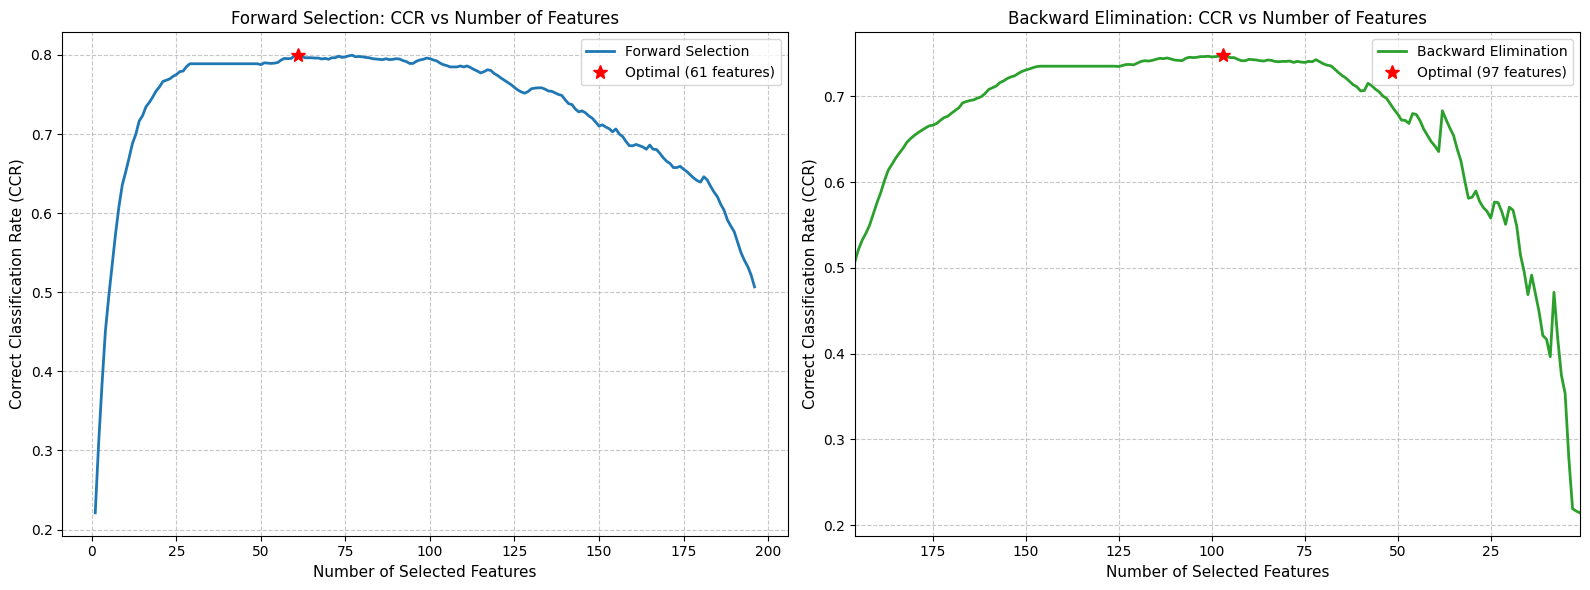

In [5]:
# Forward Selection Optimal Metrics
opt_fw_idx = np.argmax(best_scores_fw)
opt_fw_k = opt_fw_idx + 1
opt_fw_score = best_scores_fw[opt_fw_idx]

# Backward Elimination Optimal Metrics (Array represents N down to 1)
num_features_bw = np.arange(n_features, 0, -1)
opt_bw_idx = np.argmax(best_scores_bw)
opt_bw_k = num_features_bw[opt_bw_idx]
opt_bw_score = best_scores_bw[opt_bw_idx]

print(f'--- Optimal Feature Count ---')
print(f'Forward Selection: {opt_fw_k} features, Max CCR = {opt_fw_score:.4f}')
print(f'Backward Elimination: {opt_bw_k} features, Max CCR = {opt_bw_score:.4f}')

plt.figure(figsize=(16, 6))

# Forward Selection Plot
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, n_features + 1), best_scores_fw, label='Forward Selection', color='#1f77b4', linewidth=2)
plt.plot(opt_fw_k, opt_fw_score, 'r*', markersize=10, label=f'Optimal ({opt_fw_k} features)')
plt.title('Forward Selection: CCR vs Number of Features', fontsize=12)
plt.xlabel('Number of Selected Features', fontsize=11)
plt.ylabel('Correct Classification Rate (CCR)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Backward Elimination Plot
plt.subplot(1, 2, 2)
plt.plot(num_features_bw, best_scores_bw, label='Backward Elimination', color='#2ca02c', linewidth=2)
plt.plot(opt_bw_k, opt_bw_score, 'r*', markersize=10, label=f'Optimal ({opt_bw_k} features)')
plt.title('Backward Elimination: CCR vs Number of Features', fontsize=12)
plt.xlabel('Number of Selected Features', fontsize=11)
plt.ylabel('Correct Classification Rate (CCR)', fontsize=11)
plt.xlim(n_features, 1)  # Reverse x-axis to show elimination from right to left properly
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()